In [1]:
from google.colab import files
uploaded = files.upload()

Saving Sample - Superstore.csv to Sample - Superstore (1).csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('Sample - Superstore.csv', encoding='latin-1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
print(df.shape)        # กี่แถว กี่คอลัมน์
print(df.dtypes)       # ประเภทของแต่ละคอลัมน์
print(df.isnull().sum()) # มี missing value มั้ย

(9994, 21)
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [5]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(category_sales)

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64


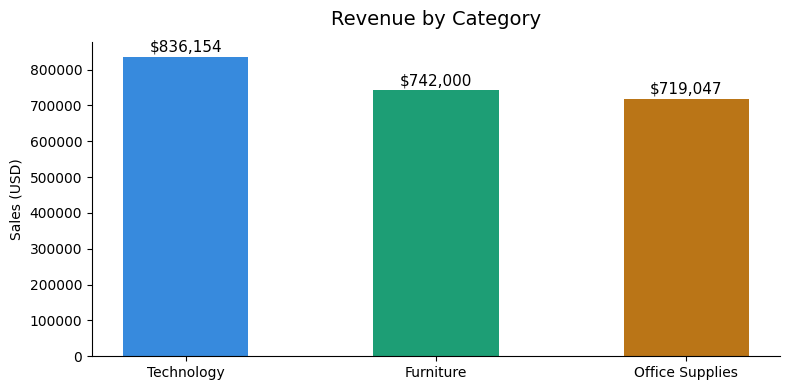

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.bar(category_sales.index, category_sales.values,
              color=['#378ADD', '#1D9E75', '#BA7517'],
              edgecolor='none', width=0.5)

# ใส่ตัวเลขบนแท่ง
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
            f"${bar.get_height():,.0f}", ha='center', va='bottom', fontsize=11)

ax.set_title('Revenue by Category', fontsize=14, pad=12)
ax.set_ylabel('Sales (USD)')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

In [7]:
profit_summary = df.groupby('Category').agg(
    Revenue=('Sales', 'sum'),
    Profit=('Profit', 'sum')
).assign(Margin=lambda x: (x['Profit'] / x['Revenue'] * 100).round(1))

print(profit_summary)

                     Revenue       Profit  Margin
Category                                         
Furniture        741999.7953   18451.2728     2.5
Office Supplies  719047.0320  122490.8008    17.0
Technology       836154.0330  145454.9481    17.4


In [8]:
sub_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()
losing = sub_profit[sub_profit < 0]
print("Sub-categories ที่ขาดทุน:")
print(losing)

Sub-categories ที่ขาดทุน:
Sub-Category
Tables      -17725.4811
Bookcases    -3472.5560
Supplies     -1189.0995
Name: Profit, dtype: float64


In [10]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

In [11]:
monthly = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()
print(monthly.tail(12))  # ดู 12 เดือนล่าสุด

    Year  Month        Sales
36  2017      1   43971.3740
37  2017      2   20301.1334
38  2017      3   58872.3528
39  2017      4   36521.5361
40  2017      5   44261.1102
41  2017      6   52981.7257
42  2017      7   45264.4160
43  2017      8   63120.8880
44  2017      9   87866.6520
45  2017     10   77776.9232
46  2017     11  118447.8250
47  2017     12   83829.3188


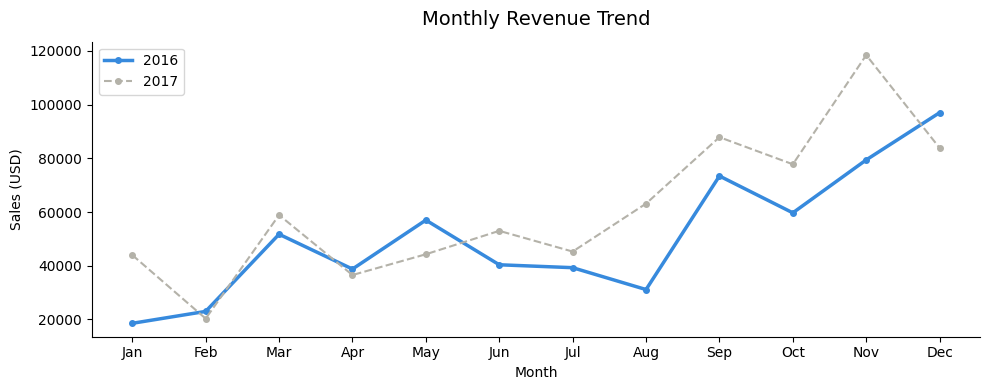

In [12]:
# แยกข้อมูลแต่ละปี
years = sorted(df['Year'].unique())
last2 = years[-2:]  # 2 ปีล่าสุด

fig, ax = plt.subplots(figsize=(10, 4))

styles = [
    {'color': '#378ADD', 'linewidth': 2.5, 'linestyle': '-'},
    {'color': '#B4B2A9', 'linewidth': 1.5, 'linestyle': '--'},
]

for i, year in enumerate(last2):
    data = monthly[monthly['Year'] == year].sort_values('Month')
    ax.plot(data['Month'], data['Sales'],
            label=str(year), **styles[i], marker='o', markersize=4)

ax.set_title('Monthly Revenue Trend', fontsize=14, pad=12)
ax.set_ylabel('Sales (USD)')
ax.set_xlabel('Month')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'])
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

In [13]:
df['Quarter'] = df['Order Date'].dt.quarter

quarterly = df.groupby(['Year','Quarter'])['Sales'].sum()
print(quarterly)

Year  Quarter
2014  1           74447.7960
      2           86538.7596
      3          143633.2123
      4          179627.7302
2015  1           68851.7386
      2           89124.1870
      3          130259.5752
      4          182297.0082
2016  1           93237.1810
      2          136082.3010
      3          143787.3622
      4          236098.7538
2017  1          123144.8602
      2          133764.3720
      3          196251.9560
      4          280054.0670
Name: Sales, dtype: float64


In [14]:
corr = df['Discount'].corr(df['Profit'])
print(f"Correlation Discount vs Profit: {corr:.2f}")

Correlation Discount vs Profit: -0.22


In [15]:
df['Profit_Flag'] = df['Profit'].apply(lambda x: 'กำไร' if x > 0 else 'ขาดทุน')

discount_summary = df.groupby('Profit_Flag')['Discount'].mean()
print(discount_summary)

Profit_Flag
กำไร      0.081044
ขาดทุน    0.469029
Name: Discount, dtype: float64


In [17]:
fig.savefig('category_sales.png', dpi=150, bbox_inches='tight')